In [63]:
graphics_toolkit("gnuplot")

In [64]:
a = 0; b = 1;            % границы отрезка
N = 5;                   % начальное число узлов
h = (b - a) / (N - 1);   % шаг сетки
x = linspace(a, b, N)'  % вектор-столбец узлов

x =

        0
   0.2500
   0.5000
   0.7500
   1.0000



In [65]:
xmid = (x(1:end-1) + x(2:end)) / 2   % середины интервалов

xmid =

   0.1250
   0.3750
   0.6250
   0.8750



In [66]:
% Функции задачи (пример)
k = @(x) 1 + 2*x.^2;
q = @(x) exp(x);
f = @(x) 20*sin(3*pi*x);

% Значения в узлах
kv = k(x)
qv = q(x)
fv = f(x)

kv =

   1.0000
   1.1250
   1.5000
   2.1250
   3.0000

qv =

   1.0000
   1.2840
   1.6487
   2.1170
   2.7183

fv =

         0
   14.1421
  -20.0000
   14.1421
    0.0000



In [67]:
kmid = k(xmid)

kmid =

   1.0312
   1.2812
   1.7812
   2.5312



Для внутренних узлов:

In [68]:
A = zeros(N, N);
B = zeros(N, 1);

for i = 2:N-1
    A(i, i-1) = -kmid(i-1) / h^2;
    A(i, i+1) = -kmid(i)   / h^2;
    A(i, i)   = (kmid(i-1) + kmid(i)) / h^2 + qv(i);
    B(i)      = fv(i);
end

In [69]:
A
B

A =

         0         0         0         0         0
  -16.5000   38.2840  -20.5000         0         0
         0  -20.5000   50.6487  -28.5000         0
         0         0  -28.5000   71.1170  -40.5000
         0         0         0         0         0

B =

         0
   14.1421
  -20.0000
   14.1421
         0



Дирихле:

In [70]:
% Дирихле слева (x=a)
A(1,1) = 1;   B(1) = 0;   % u(0) = 0
% Дирихле справа (x=b)
A(N,N) = 1;   B(N) = 0;   % u(1) = 0

In [71]:
A
B

A =

    1.0000         0         0         0         0
  -16.5000   38.2840  -20.5000         0         0
         0  -20.5000   50.6487  -28.5000         0
         0         0  -28.5000   71.1170  -40.5000
         0         0         0         0    1.0000

B =

         0
   14.1421
  -20.0000
   14.1421
         0



In [72]:
a_diag = diag(A, -1);   % поддиагональ (ниже главной), длина N-1
b_diag = diag(A);       % главная диагональ, длина N
c_diag = diag(A, 1);    % наддиагональ (выше главной), длина N-1
d_vec  = B;             % правая часть

Метод прогонки:

In [73]:
function x = tridiag_solve(a, b, c, d)
    % a – поддиагональ (длины n-1), b – диагональ (n), c – наддиагональ (n-1)
    n = length(d);
    % прямой ход: исключение
    for i = 2:n
        w = a(i-1) / b(i-1);
        b(i) = b(i) - w * c(i-1);
        d(i) = d(i) - w * d(i-1);
    end
    % обратный ход
    x = zeros(n,1);
    x(n) = d(n) / b(n);
    for i = n-1:-1:1
        x(i) = (d(i) - c(i) * x(i+1)) / b(i);
    end
end

In [74]:
U = tridiag_solve(a_diag, b_diag, c_diag, d_vec);
U

U =

        0
   0.2413
  -0.2393
   0.1030
        0



N = 9, h = 0.125000, погрешность = 2.352148e-02
N = 17, h = 0.062500, погрешность = 6.360416e-03
N = 33, h = 0.031250, погрешность = 1.515024e-03
N = 65, h = 0.015625, погрешность = 3.861309e-04
N = 129, h = 0.007812, погрешность = 9.613404e-05

Точность достигнута. Число узлов = 129, h = 0.007812


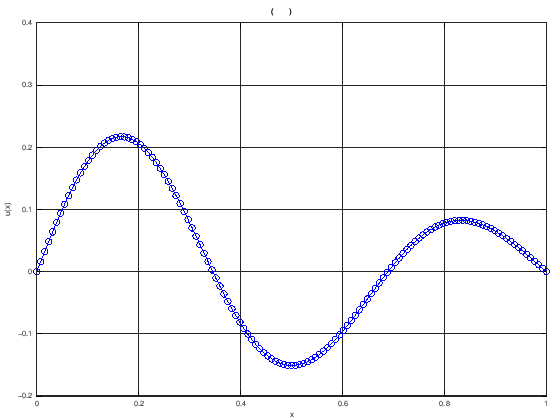

In [78]:
% Очистим переменные и определим функции заново
clear;

a = 0; b = 1;
k = @(x) 1 + 2*x.^2;
q = @(x) exp(x);
f = @(x) 20*sin(3*pi*x);

tol = 1e-4;
N = 5;
err_est = tol + 1;
first = true;

while err_est > tol
    % Сетка
    h = (b - a)/(N - 1);
    x = linspace(a, b, N)';
    xmid = (x(1:end-1) + x(2:end))/2;
    
    % Значения функций
    kmid = k(xmid);
    qv = q(x);
    fv = f(x);
    
    % Диагонали и правая часть
    a_diag = zeros(N,1);
    b_diag = zeros(N,1);
    c_diag = zeros(N,1);
    d_vec = zeros(N,1);
    
    % Внутренние узлы (i = 2..N-1)
    for i = 2:N-1
        a_diag(i-1) = -kmid(i-1)/h^2;   % под главной диагональю для строки i
        c_diag(i)   = -kmid(i)/h^2;     % над главной диагональю для строки i
        b_diag(i)   = (kmid(i-1) + kmid(i))/h^2 + qv(i);
        d_vec(i)    = fv(i);
    end
    
    % Граничные условия Дирихле: u(0)=0, u(1)=0
    b_diag(1) = 1; c_diag(1) = 0; d_vec(1) = 0;
    a_diag(N-1) = 0; b_diag(N) = 1; d_vec(N) = 0;
    
    % Подготовка массивов для прогонки
    aa = a_diag(1:N-1);   % поддиагональ (длина N-1)
    cc = c_diag(1:N-1);   % наддиагональ (длина N-1)
    
    % Решение методом прогонки
    U = tridiag_solve(aa, b_diag, cc, d_vec);
    
    % Оценка погрешности по Рунге
    if ~first
        U_coarse = U(1:2:end);   % узлы, совпадающие с предыдущей (грубой) сеткой
        err_est = max(abs(U_coarse - U_prev)) / 3;
        fprintf('N = %d, h = %.6f, погрешность = %.6e\n', N, h, err_est);
    else
        first = false;
    end
    
    U_prev = U;
    N = 2*N - 1;
end

% Результаты на финальной сетке
x_final = x;     % последняя использованная сетка
U_final = U;     % последнее решение
fprintf('\nТочность достигнута. Число узлов = %d, h = %.6f\n', length(x_final), (b-a)/(length(x_final)-1));

% График решения
graphics_toolkit("gnuplot");  % если нужно
figure(1)
plot(x_final, U_final, 'b-o', 'LineWidth', 1.5);
xlabel('x'); ylabel('u(x)');
title('Решение краевой задачи (Дирихле)');
grid on;